# Bank Analysis

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statistics

In [3]:
df = pd.read_csv("/home/jawad/Downloads/bank_analysis_dataset.csv")
df

,CustomerID,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,AccountType,NumComplaints,MonthlyTransactions,SatisfactionScore,Exited
0,10000001,Miller,474,France,Female,58,4,33771.50,1,0,1,159997.24,Savings,0,10,4,0
1,10000002,Martin,668,France,Male,27,5,41136.87,2,1,0,7590.47,Savings,0,20,3,0
2,10000003,Anderson,436,France,Male,24,5,32507.20,3,0,0,53511.70,Savings,0,10,2,1
3,10000004,Hernandez,390,France,Male,68,2,76530.95,3,0,0,124427.46,Current,0,14,5,0
4,10000005,Davis,819,Germany,Male,41,10,12451.30,1,1,1,121929.64,Savings,0,6,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,10009996,Johnson,532,France,Male,44,1,0.00,1,0,1,158824.50,Savings,1,10,5,0
9996,10009997,Hernandez,426,Germany,Female,67,5,0.00,3,0,1,81254.29,Current,1,10,2,0
9997,10009998,Johnson,674,France,Male,79,4,12988.62,1,1,0,74569.11,Current,3,11,3,1
9998,10009999,Smith,393,Germany,Female,59,10,0.00,4,0,0,123585.30,Fixed Deposit,1,10,4,1


# Data cleaning

In [ ]:
print(df.head())
print("\n")
print(df.describe())

print("\nnull value : ",df.isnull().sum())
print("\nduplicated count : ",df.duplicated().sum())
df = df.drop_duplicates()
df["Balance"] = df["Balance"].fillna(df["Balance"].median())
df["CreditScore"] = df["CreditScore"].fillna(df["CreditScore"].median())
df["Age"] = df["Age"].fillna(df["Age"].mode())
# invalid values
print(df["Balance"] < 0)
print(df["Age"] < 0)
print(df["CreditScore"] < 0)
print(df[(df["Age"] < 18) |(df["Age"] > 100) ])
# data types\
print("\n\n")
print("Data types : ",df.dtypes)
df["Age"] = df["Age"].astype(int)
df["Balance"] = df["Balance"].astype(int)
df["EstimatedSalary"] =df["EstimatedSalary"].astype(int)
df["Gender"] = df["Gender"].astype("category")


   CustomerID    Surname  CreditScore Geography  Gender  Age  Tenure  Balance  \
0    10000001     Miller          474    France  Female   58       4    33771   
1    10000002     Martin          668    France    Male   27       5    41136   
2    10000003   Anderson          436    France    Male   24       5    32507   
3    10000004  Hernandez          390    France    Male   68       2    76530   
4    10000005      Davis          819   Germany    Male   41      10    12451   

   NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary AccountType  \
0              1          0               1           159997     Savings   
1              2          1               0             7590     Savings   
2              3          0               0            53511     Savings   
3              3          0               0           124427     Current   
4              1          1               1           121929     Savings   

   NumComplaints  MonthlyTransactions  SatisfactionScore

In [5]:
# outliers 
Q1 = df["Balance"].quantile(0.25)
Q3 = df["Balance"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)
print("Quartile ist : ", Q1)
print("Quartile third : ",Q3)
print ("inter quartile range : ", IQR.round(3))
print("lower_bound :",lower_bound)
print("upper_bound : ",upper_bound)
outliers = []
for i in df["Balance"]:
    if (i < lower_bound) or (i > upper_bound):
        outliers.append(i)


print("number of outliers : ",len(outliers))


Quartile ist :  0.0
Quartile third :  42737.0
inter quartile range :  42737.0
lower_bound : -64105.5
upper_bound :  106842.5
number of outliers :  598


# Exploratray Data Analysis

In [21]:
# Average age of the customer 
Avg_Age_cust = df["Age"].mean()
print("Average Age of customers : ",Avg_Age_cust.round(1))
# Average Income 
Avg_Balance = df["Balance"].mean()
print("Average Balance of the customer : ", Avg_Balance.round(3))
# Average of monthly transiction
Avg_monthly_trans = df["MonthlyTransactions"].mean()
print("Average monthly transiction : ", Avg_monthly_trans.round(3))
# Standard deviation of all credit score 
std_of_creditscore = np.std(df["CreditScore"])
print("Standard deviation of all credit score : ", std_of_creditscore.round(3))
# number of complaints
number_complaints = df["NumComplaints"].sum()
print("Total number of complaints : ", number_complaints)

Average Age of customers :  48.5
Average Balance of the customer :  29013.596
Average monthly transiction :  11.988
Standard deviation of all credit score :  144.528
Total number of complaints :  3959


# Visualaization 

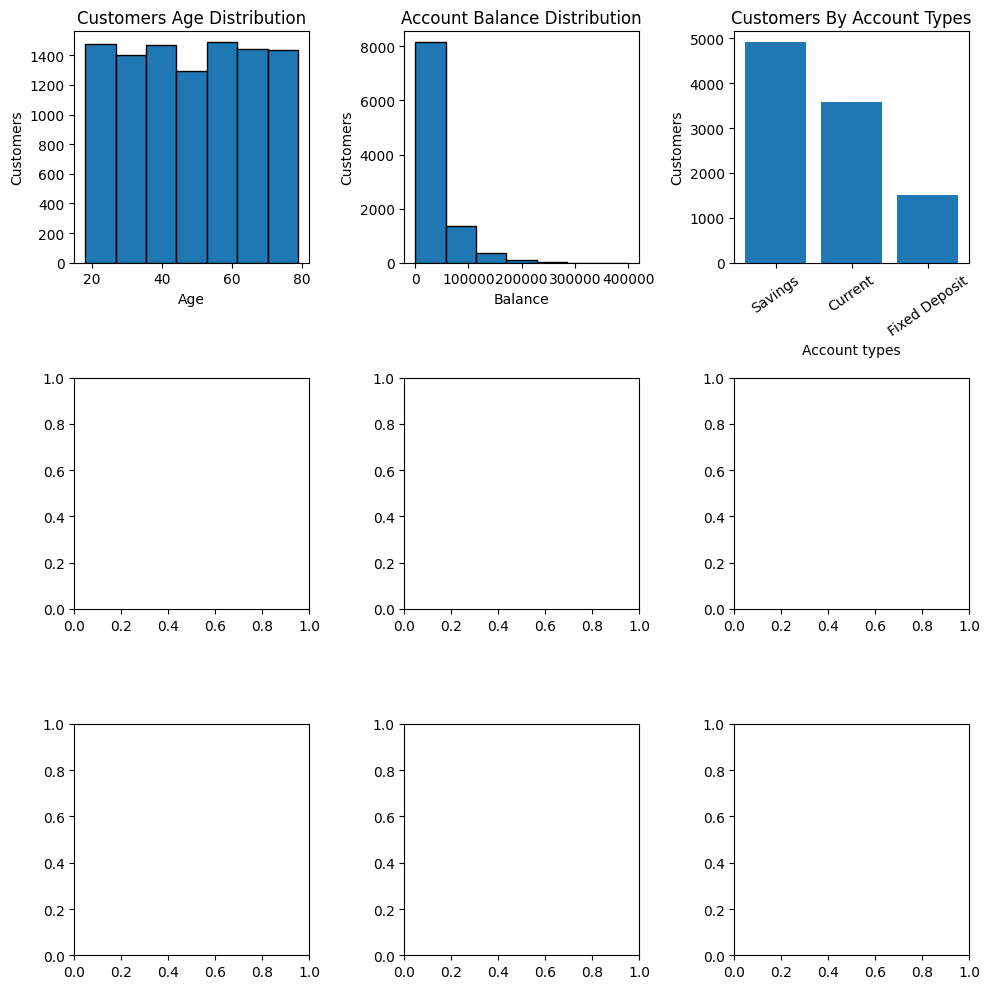

In [39]:
fig,ax = plt.subplots(3,3,figsize=(10,10))
# ist subplot
# age distribution
ax[0,0].hist(df["Age"],bins=7,edgecolor="Black")
ax[0,0].set_title("Customers Age Distribution")
ax[0,0].set_xlabel("Age")
ax[0,0].set_ylabel("Customers")

# 2nd subplot
# Account balance distribution
ax[0,1].hist(df["Balance"],bins=7,edgecolor="black")
ax[0,1].set_title("Account Balance Distribution")
ax[0,1].set_xlabel("Balance")
ax[0,1].set_ylabel("Customers")

# 3rd subplot
# customers by account type
cus_by_acc = df["AccountType"].value_counts()
ax[0,2].bar(cus_by_acc.index,cus_by_acc.values)
ax[0,2].tick_params(axis = "x",rotation=35)
ax[0,2].set_title("Customers By Account Types")
ax[0,2].set_xlabel("Account types")
ax[0,2].set_ylabel("Customers")


plt.tight_layout()
plt.show()